In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR
from dms_rnn.dms_model import DMSRNN
from dms_rnn.task_design import generate_dms_batch, make_loss_mask
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
torch.manual_seed(2026)
# 1. Initialize our biological network and the learning tools
model = DMSRNN(input_size=2, hidden_size=200,dt=1, tau=100)  # 100 neurons in the hidden layer
model = model.to(device)

# Instead of passing all model.parameters(), we only pass the ones that require gradients
trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())

# Initialize the optimizer with only the trainable parameters
optimizer = optim.Adam(trainable_parameters, lr=0.1,betas=(0.9, 0.999), eps=0.1, weight_decay=0.0)
criterion = nn.MSELoss() # Our continuous evidence accumulator loss

epochs = 300
batch_size = 64
loss_history = []

sample_dur=450
test_dur=450
delay_min=200
delay_max=600

scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=0.0001,total_iters=epochs)
# 2. The Training Loop
for epoch in range(epochs):
    # Generate a fresh, procedurally generated batch of trials
    x_batch, y_batch, delays = generate_dms_batch(batch_size, sample_dur=sample_dur, test_dur=test_dur, delay_min=delay_min, delay_max=delay_max, noise_std=0.1)
    mask = make_loss_mask(batch_size, delays, sample_dur=sample_dur, test_dur=test_dur, delay_max=delay_max).to(device).T
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    
    optimizer.zero_grad() # Clear old gradients
    
    output_sequence, rnn_activity = model(x_batch) 
    
    # Calculate the error between the network's final accumulator state and the target (+1 or -1)
    y_expanded = y_batch.unsqueeze(0).expand_as(output_sequence).squeeze(2)
    loss = criterion(output_sequence.squeeze(2) * mask, y_expanded * mask) # We only calculate loss during the time steps when the network should be accumulating evidence, not during the delay period when it should be holding still.
    
    # Backward pass: BPTT calculates how to change the weights to reduce the error
    loss.backward() 
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    # if norm > 1.0:
    #     print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Grad Norm: {norm:.4f}")

    # Update weights
    optimizer.step()
    scheduler.step()
    # Save the numerical value of the loss at this epoch
    loss_history.append(loss.item())
    if epoch % 10  == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 0.3337
Epoch 10 | Loss: 0.2753
Epoch 20 | Loss: 0.2418
Epoch 30 | Loss: 0.1336
Epoch 40 | Loss: 0.0518
Epoch 50 | Loss: 0.0358
Epoch 60 | Loss: 0.0327
Epoch 70 | Loss: 0.0319
Epoch 80 | Loss: 0.0296
Epoch 90 | Loss: 0.0269
Epoch 100 | Loss: 0.0269
Epoch 110 | Loss: 0.0271
Epoch 120 | Loss: 0.0258
Epoch 130 | Loss: 0.0253
Epoch 140 | Loss: 0.0246
Epoch 150 | Loss: 0.0245
Epoch 160 | Loss: 0.0244
Epoch 170 | Loss: 0.0240
Epoch 180 | Loss: 0.0239
Epoch 190 | Loss: 0.0234
Epoch 200 | Loss: 0.0236
Epoch 210 | Loss: 0.0230
Epoch 220 | Loss: 0.0233
Epoch 230 | Loss: 0.0231
Epoch 240 | Loss: 0.0230
Epoch 250 | Loss: 0.0230
Epoch 260 | Loss: 0.0228
Epoch 270 | Loss: 0.0225
Epoch 280 | Loss: 0.0224
Epoch 290 | Loss: 0.0224


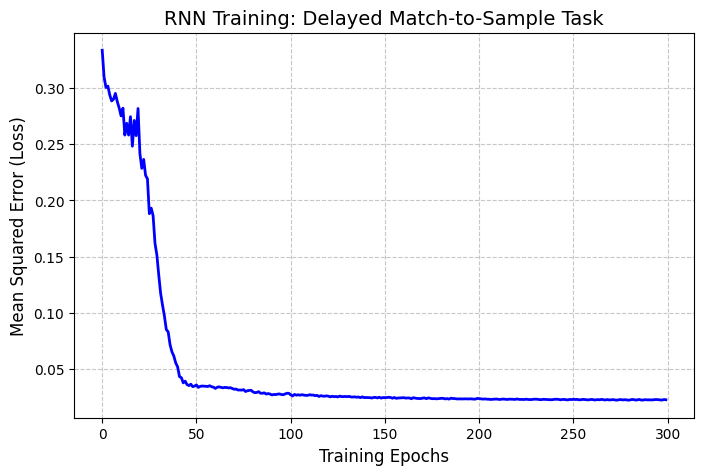

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history[:], color='blue', linewidth=2)
plt.title("RNN Training: Delayed Match-to-Sample Task", fontsize=14)
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (Loss)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
x_batch, y_batch, delays = generate_dms_batch(batch_size, sample_dur=sample_dur, test_dur=test_dur, delay_min=400, delay_max=400, noise_std=0.1)
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
output_sequence, rnn_activity = model(x_batch) 
rnn_activity = rnn_activity.detach().cpu().numpy()
y_batch = y_batch.detach().cpu().numpy()
x_batch = x_batch.detach().cpu().numpy()

In [10]:
x_batch.shape

(64, 1300, 2)

In [11]:
from sklearn.decomposition import PCA
ncomp=2
pca = PCA(n_components=ncomp)
pcs = pca.fit_transform(rnn_activity.reshape(-1,rnn_activity.shape[2]))
pcs = pcs.reshape(-1, 64, ncomp)

In [14]:
pca.explained_variance_ratio_

array([0.61481816, 0.19296297], dtype=float32)

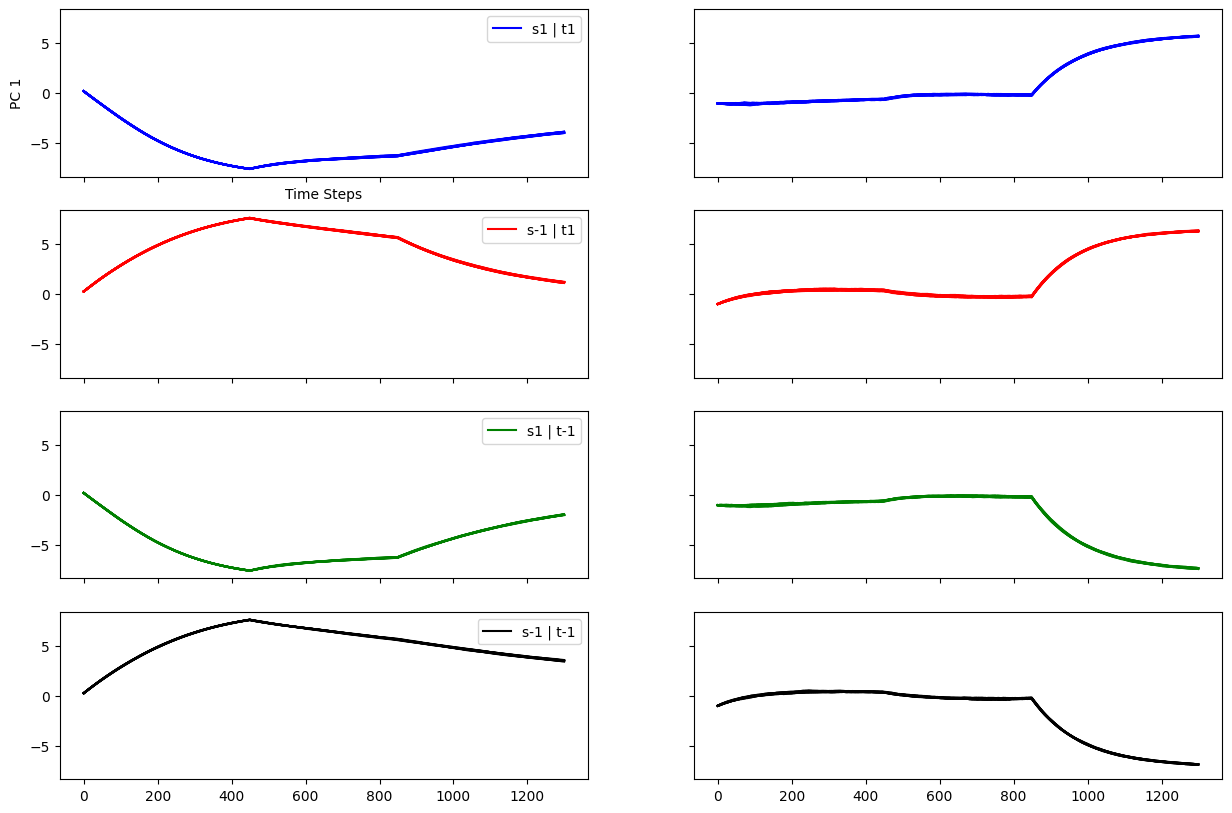

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(4, ncomp, sharey=True, sharex=True, figsize=(15, 10))

# Track which rows have been labeled
labeled_rows = set()

for itrial in range(64):
     test_val = x_batch[itrial,900,1] > 0
     sample_val = x_batch[itrial,0,0] > 0

     if np.logical_and(test_val, sample_val):
          color = 'b'
          label = 's1 | t1' if 0 not in labeled_rows else None
          labeled_rows.add(0)
          for ipc in range(ncomp):
               _ = ax[0,ipc].plot(pcs[:, itrial, ipc], color=color, label=label)

          
     elif np.logical_and(test_val, not sample_val):
          color = 'r'
          label = 's-1 | t1' if 1 not in labeled_rows else None
          labeled_rows.add(1)
          for ipc in range(ncomp):
               _ = ax[1,ipc].plot(pcs[:, itrial, ipc], color=color, label=label)

     elif np.logical_and(not test_val,  sample_val):
          color = 'g'
          label = 's1 | t-1' if 2 not in labeled_rows else None
          labeled_rows.add(2)
          for ipc in range(ncomp):
               _ = ax[2,ipc].plot(pcs[:, itrial, ipc], color=color, label=label)
     else:
          color = 'k'
          label = 's-1 | t-1' if 3 not in labeled_rows else None
          labeled_rows.add(3)
          for ipc in range(ncomp):
               _ = ax[3,ipc].plot(pcs[:, itrial, ipc], color=color, label=label)

ax[0,0].set_xlabel('Time Steps')
ax[0,0].set_ylabel('PC 1')
ax[0,0].legend(loc='upper right')
ax[1,0].legend(loc='upper right')
ax[2,0].legend(loc='upper right')
ax[3,0].legend(loc='upper right')

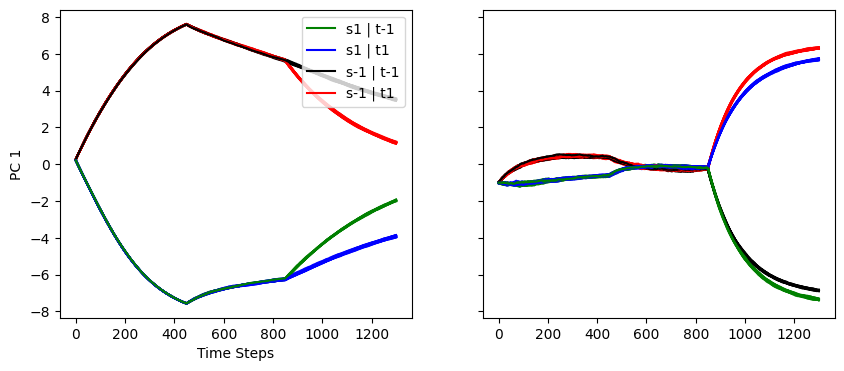

In [13]:
fig, ax = plt.subplots(1, ncomp, sharey=True, sharex=True, figsize=(10, 4))

# Track which rows have been labeled
labeled_rows = set()

for itrial in range(64):
     test_val = x_batch[itrial,900,1] > 0
     sample_val = x_batch[itrial,0,0] > 0

     if np.logical_and(test_val, sample_val):
          color = 'b'
          label = 's1 | t1' if 0 not in labeled_rows else None
          labeled_rows.add(0)
          for ipc in range(ncomp):
               _ = ax[ipc].plot(pcs[:, itrial, ipc], color=color, label=label)

          
     elif np.logical_and(test_val, not sample_val):
          color = 'r'
          label = 's-1 | t1' if 1 not in labeled_rows else None
          labeled_rows.add(1)
          for ipc in range(ncomp):
               _ = ax[ipc].plot(pcs[:, itrial, ipc], color=color, label=label)

     elif np.logical_and(not test_val,  sample_val):
          color = 'g'
          label = 's1 | t-1' if 2 not in labeled_rows else None
          labeled_rows.add(2)
          for ipc in range(ncomp):
               _ = ax[ipc].plot(pcs[:, itrial, ipc], color=color, label=label)
     else:
          color = 'k'
          label = 's-1 | t-1' if 3 not in labeled_rows else None
          labeled_rows.add(3)
          for ipc in range(ncomp):
               _ = ax[ipc].plot(pcs[:, itrial, ipc], color=color, label=label)

ax[0].set_xlabel('Time Steps')
ax[0].set_ylabel('PC 1')
ax[0].legend(loc='upper right')